In [4]:
# Na self-diffusion from VACF (Green–Kubo) for multiple models (Jupyter version)
# - Saves: VACF_<MODEL>_Na.csv and GK_integral_<MODEL>_Na.csv (with cumulative integrals)
# - Summaries: D_summary.csv
# - Optional quick plots: set MAKE_PLOTS = True

from pathlib import Path
import numpy as np
import pandas as pd
from ase.io.trajectory import Trajectory
from ase.geometry import find_mic
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# ----------------------------- user config -----------------------------
OUT_DIR         = Path("vacf_diffusion_out")
DT_FS_FALLBACK  = 10.0      # fs, used if step not in traj
STRIDE          = 1         # temporal stride
TMAX_PS         = None      # e.g. 200.0 to crop, or None
TAIL_FIT        = False     # set True to add exp tail after first zero crossing
TAIL_WINDOW_PS  = 1.5       # size of window after zero crossing for exp fit
MAKE_PLOTS      = False     # quick PNGs of VACF and D(t)
SPECIES         = "Na"      # which species to analyze

model_trajs = {
    "UMA-OMol": [
        "/Volumes/drive_n1/nitesh_projs_Y2/LBL_proj/Battery_project_lbl/bat_esra/1M_NaPF6_DME_uma/NPT_sims/md_omol_re5_small_new_1p1.traj",
    ],
    "Distilled-OMol": [
        "napf6_s1p1_distilled_1ns.traj",
    ],
}

# ----------------------------- helpers -----------------------------
def infer_dt_fs(times):
    if times is None or len(times) < 2:
        return None
    return float(np.median(np.diff(times)))

def collect_times(frames):
    """Return times in fs if stored in atoms.info['time'] per frame, else None."""
    t = []
    for at in frames:
        ti = at.info.get("time", None)
        if ti is None:
            return None
        t.append(float(ti))
    return np.asarray(t, float)

def unwrap_positions(frames, cell):
    """Unwrap PBC positions by cumulative minimum-image displacements."""
    T = len(frames)
    R = [frames[0].get_positions(wrap=True)]
    for t in range(1, T):
        r_prev = R[-1]
        r_now  = frames[t].get_positions(wrap=True)
        disp   = find_mic(r_now - r_prev, cell, pbc=True)[0]
        R.append(r_prev + disp)
    return np.stack(R, axis=0)  # [T, N, 3]

def estimate_velocities_from_positions(R, dt_fs):
    """Central difference velocities; endpoints via forward/backward difference."""
    V = np.zeros_like(R)
    V[1:-1] = (R[2:] - R[:-2]) / (2.0 * dt_fs)
    V[0]    = (R[1] - R[0]) / dt_fs
    V[-1]   = (R[-1] - R[-2]) / dt_fs
    return V  # Å/fs

def vacf_fft_multi(V, stride=1, max_lag=None):
    """
    VACF via FFT for multi-particle velocities.
    V: [T, N, 3] in Å/fs
    Returns: vacf[0..max_lag] (Å^2/fs^2)
    """
    V = V[::stride]
    T, N, D = V.shape
    if max_lag is None:
        max_lag = T - 1

    Vm = V - V.mean(axis=0, keepdims=True)          # remove drift per particle
    X  = Vm.reshape(T, N * D)                        # stack series

    nfft = 1 << (2 * T - 1).bit_length()
    F    = np.fft.rfft(X, n=nfft, axis=0)
    S    = F * np.conjugate(F)
    ac   = np.fft.irfft(S, n=nfft, axis=0)[:T]
    ac  /= (np.arange(T, 0, -1))[:, None]           # unbiased normalization
    vacf = ac.mean(axis=1)[:max_lag + 1]
    return vacf

def first_zero_crossing(y):
    for i in range(1, len(y)):
        if y[i-1] > 0.0 and y[i] <= 0.0:
            return i
    return None

def cumulative_trapz(y, dx):
    """cumtrapz with out[0]=0. Same length as y."""
    out = np.zeros_like(y, dtype=float)
    if len(y) < 2:
        return out
    # out[i] = sum_{k=1..i} 0.5*(y[k-1]+y[k])*dx
    out[1:] = np.cumsum(0.5*(y[1:] + y[:-1]) * dx)
    return out

def fit_exponential_tail(t, y):
    """
    Fit y ≈ A * exp(-t/τ) on a positive segment (nonlinear via log).
    Returns (A, tau_ps) or None if not sensible.
    """
    mask = y > 0
    if mask.sum() < 5:
        return None
    t_pos = t[mask]
    y_pos = y[mask]
    logy  = np.log(y_pos)
    A = np.vstack([np.ones_like(t_pos), -t_pos]).T
    sol, *_ = np.linalg.lstsq(A, logy, rcond=None)
    logA, inv_tau = sol
    if inv_tau <= 0:
        return None
    return np.exp(logA), 1.0 / inv_tau

# ----------------------------- core routine -----------------------------
def process_model(name, paths):
    # load and concatenate frames
    frames = []
    for p in paths:
        pth = Path(p)
        if not pth.exists():
            print(f"[{name}] missing file {p}")
            continue
        with Trajectory(p) as tr:
            frames.extend([at.copy() for at in tr])

    if len(frames) < 8:
        raise RuntimeError(f"[{name}] not enough frames")

    # species indices
    sym = np.array(frames[0].get_chemical_symbols())
    idx = np.where(sym == SPECIES)[0]
    if len(idx) == 0:
        raise RuntimeError(f"[{name}] no {SPECIES} found")

    # timestep
    times_fs = collect_times(frames)                 # fs or None
    dt_fs    = infer_dt_fs(times_fs) or DT_FS_FALLBACK

    # unwrap positions, get velocities (or estimate)
    cell  = frames[0].cell
    R_all = unwrap_positions(frames, cell)[:, idx, :]

    try:
        V_all = np.stack([at.get_velocities() for at in frames], axis=0)[:, idx, :]
        if np.isnan(V_all).any():
            raise ValueError
    except Exception:
        V_all = estimate_velocities_from_positions(R_all, dt_fs)

    # optional crop
    T_total    = V_all.shape[0]
    total_ps   = dt_fs * T_total * 1e-3
    if TMAX_PS is not None and total_ps > TMAX_PS:
        T_keep = int(TMAX_PS * 1e3 / dt_fs)
        V_all  = V_all[:T_keep]
        total_ps = dt_fs * V_all.shape[0] * 1e-3

    # VACF
    vacf        = vacf_fft_multi(V_all, stride=STRIDE)
    dt_eff_fs   = dt_fs * STRIDE
    t_ps        = np.arange(len(vacf)) * dt_eff_fs * 1e-3

    # first zero crossing
    iz = first_zero_crossing(vacf)
    if iz is None:
        iz = len(vacf) - 1
    t_zero_ps = float(t_ps[iz])

    # cumulative integrals
    # base units: vacf is Å^2/fs^2; integral over time (fs) gives Å^2/fs; prefactor 1/3 for GK
    GK_A2_per_fs = (1.0/3.0) * cumulative_trapz(vacf, dx=dt_eff_fs)  # Å^2/fs
    # convert to SI (m^2/s): 1 Å^2/fs = (1e-20 m^2) / (1e-15 s) = 1e-5 m^2/s
    GK_SI_m2_s   = GK_A2_per_fs * 1e-5

    # truncate-at-zero-crossing diffusion
    D_base_SI = GK_SI_m2_s[iz]
    note = "integral to first zero crossing"
    use_tail = False

    # optional exponential tail after zero crossing
    if TAIL_FIT and iz < len(vacf) - 5:
        t0   = t_ps[iz]
        w    = float(TAIL_WINDOW_PS)
        mask = (t_ps >= t0) & (t_ps <= min(t0 + w, t_ps[-1]))
        fit  = fit_exponential_tail(t_ps[mask] - t0, vacf[mask])
        if fit is not None:
            A, tau_ps = fit
            # ∫_{t0}^{∞} (1/3) A exp(-(t-t0)/τ) dt = (1/3) * A * τ (with t in same units as τ)
            D_tail_SI = (1.0/3.0) * A * tau_ps * 1e-5  # since A in Å^2/fs^2 and tau in ps -> (ps to fs via 1e3) already handled by 1e-5 factor? 
            # Careful: A units Å^2/fs^2; τ in ps -> convert τ to fs before multiplying by 1e-5
            D_tail_SI = (1.0/3.0) * A * (tau_ps * 1e3) * 1e-5  # now consistent
            D_base_SI += D_tail_SI
            note += f" + exp tail fit over {w:.2f} ps"
            use_tail = True
        else:
            note += " (tail fit failed)"

    # save curves
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    pd.DataFrame({"time_ps": t_ps, "VACF_A2fs2": vacf}).to_csv(OUT_DIR / f"VACF_{name}_{SPECIES}.csv", index=False)
    pd.DataFrame({
        "time_ps": t_ps,
        "GK_int_A2_per_fs": GK_A2_per_fs,
        "GK_int_SI_m2_s": GK_SI_m2_s
    }).to_csv(OUT_DIR / f"GK_integral_{name}_{SPECIES}.csv", index=False)

    # optional plots
    if MAKE_PLOTS:
        plt.figure(); plt.plot(t_ps, vacf, lw=2)
        plt.xlabel("time (ps)"); plt.ylabel(r"VACF (Å$^2$/fs$^2$)")
        plt.title(f"VACF {SPECIES} — {name}"); plt.tight_layout()
        plt.savefig(OUT_DIR / f"VACF_{name}_{SPECIES}.png", dpi=160); plt.close()

        plt.figure(); plt.plot(t_ps, GK_SI_m2_s, lw=2)
        plt.axvline(t_zero_ps, ls="--", alpha=0.6)
        plt.xlabel("time (ps)"); plt.ylabel(r"$D(t)$ from GK integral (m$^2$/s)")
        plt.title(f"Green–Kubo integral {SPECIES} — {name}"); plt.tight_layout()
        plt.savefig(OUT_DIR / f"GK_integral_{name}_{SPECIES}.png", dpi=160); plt.close()

    return {
        "model": name,
        "dt_fs": dt_eff_fs,
        "n_frames": V_all.shape[0],
        "n_"+SPECIES: len(idx),
        "t_max_ps": float(dt_eff_fs * len(vacf) * 1e-3),
        "t_int_ps": float(t_ps[iz]),
        "t_zero_ps": float(t_zero_ps),
        "use_tail": use_tail,
        "D_SI_m2_s": float(D_base_SI),
        "D_cm2_s": float(D_base_SI * 1e4),
        "D_1e5_cm2_s": float(D_base_SI * 1e9),  # cm^2/s × 1e5
        "note": note,
    }

# ----------------------------- run -----------------------------
rows = []
for model, paths in model_trajs.items():
    try:
        row = process_model(model, paths)
        rows.append(row)
        print(f"[{model}] D = {row['D_cm2_s']:.4e} cm^2/s  (x1e5 = {row['D_1e5_cm2_s']:.3f})  {row['note']}")
    except Exception as e:
        print(f"[{model}] failed: {e}")

if rows:
    pd.DataFrame(rows).to_csv(OUT_DIR / "D_summary.csv", index=False)
    print(f"Saved summary to {OUT_DIR / 'D_summary.csv'}")


[UMA-OMol] D = 1.1737e-03 cm^2/s  (x1e5 = 117.375)  integral to first zero crossing
[Distilled-OMol] D = 1.2572e-04 cm^2/s  (x1e5 = 12.572)  integral to first zero crossing
Saved summary to vacf_diffusion_out/D_summary.csv


In [ ]:
### plotting 

,model,dt_fs,n_points,t_zero_ps,D_at_zero_m2_s,D_at_zero_cm2_s,csv_saved
0,Distilled-OMol,100.0,10001,0.10,1.257175e-07,0.001257,vacf_diffusion_out/GK_integral_recomputed_Dist...
1,UMA-OMol,10.0,13973,0.05,1.173746e-07,0.001174,vacf_diffusion_out/GK_integral_recomputed_UMA-...


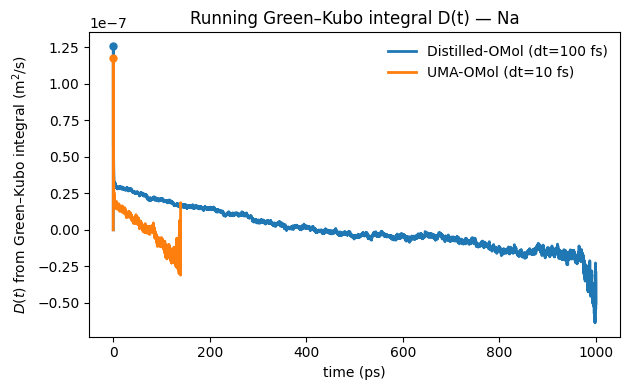

In [6]:
# Load VACF, compute and plot running D(t) for each model
# - Uses your specified dt: Distilled-OMol = 1 fs, UMA-OMol = 10 fs
# - Reads VACF_<MODEL>_Na.csv from vacf_diffusion_out/
# - Saves GK_integral_recomputed_<MODEL>_Na.csv with D(t) in Å^2/fs and m^2/s

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT_DIR = Path("vacf_diffusion_out")
SPECIES = "Na"

# Your requested timesteps (fs)
model_dt_fs = {
    "Distilled-OMol": 100.0,   # fs
    "UMA-OMol":       10.0,  # fs
}

def cumulative_trapz(y, dx):
    """cumtrapz with same length as y and out[0]=0."""
    out = np.zeros_like(y, dtype=float)
    if len(y) > 1:
        out[1:] = np.cumsum(0.5*(y[1:] + y[:-1]) * dx)
    return out

def first_zero_crossing(y):
    for i in range(1, len(y)):
        if y[i-1] > 0.0 and y[i] <= 0.0:
            return i
    return None

plt.figure(figsize=(6.4, 4.0))

summary_rows = []

for model, dt_fs in model_dt_fs.items():
    vacf_path = OUT_DIR / f"VACF_{model}_{SPECIES}.csv"
    if not vacf_path.exists():
        print(f"[warn] Missing {vacf_path}, skipping {model}")
        continue

    # --- load VACF ---
    df = pd.read_csv(vacf_path)
    # If time_ps is already there, we still recompute using your specified dt
    n = len(df)
    vacf = df["VACF_A2fs2"].to_numpy()             # Å^2/fs^2
    t_ps = np.arange(n, dtype=float) * dt_fs * 1e-3

    # --- running GK integral ---
    # (1/3) ∫_0^t VACF(τ) dτ
    GK_A2_per_fs = (1.0/3.0) * cumulative_trapz(vacf, dx=dt_fs)  # Å^2/fs
    GK_SI_m2_s   = GK_A2_per_fs * 1e-5                            # m^2/s (since 1 Å^2/fs = 1e-5 m^2/s)

    # --- first zero crossing diagnostic ---
    iz = first_zero_crossing(vacf) or (n - 1)
    D_at_zero = GK_SI_m2_s[iz]

    # --- save recomputed integral ---
    out_csv = OUT_DIR / f"GK_integral_recomputed_{model}_{SPECIES}.csv"
    pd.DataFrame({
        "time_ps": t_ps,
        "GK_int_A2_per_fs": GK_A2_per_fs,
        "GK_int_SI_m2_s": GK_SI_m2_s,
    }).to_csv(out_csv, index=False)

    # --- plot ---
    plt.plot(t_ps, GK_SI_m2_s, lw=2, label=f"{model} (dt={dt_fs:.0f} fs)")
    plt.scatter([t_ps[iz]], [D_at_zero], s=25, zorder=3)

    summary_rows.append({
        "model": model,
        "dt_fs": dt_fs,
        "n_points": n,
        "t_zero_ps": float(t_ps[iz]),
        "D_at_zero_m2_s": float(D_at_zero),
        "D_at_zero_cm2_s": float(D_at_zero * 1e4),
        "csv_saved": str(out_csv),
    })

plt.xlabel("time (ps)")
plt.ylabel(r"$D(t)$ from Green–Kubo integral (m$^2$/s)")
plt.title(f"Running Green–Kubo integral D(t) — {SPECIES}")
plt.legend(frameon=False)
plt.tight_layout()

# Optional: save the figure
plt.savefig(OUT_DIR / f"GK_integral_running_{SPECIES}.png", dpi=180)

# Show a quick summary table
if summary_rows:
    display(pd.DataFrame(summary_rows))


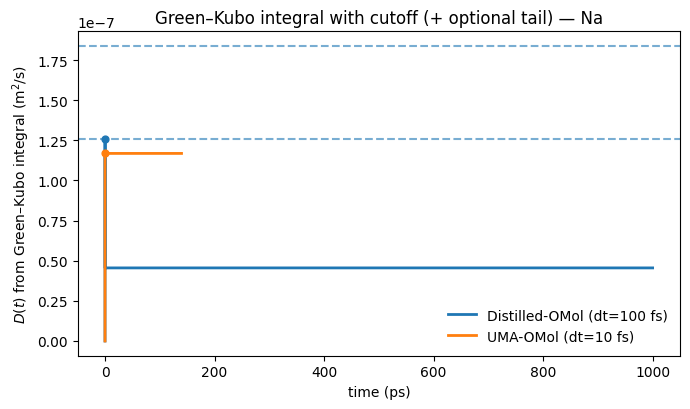

,model,dt_fs,n_points,t_zero_ps,D_cut_SI_m2_s,D_tail_SI_m2_s,D_est_SI_m2_s,D_est_cm2_s,csv_saved
0,Distilled-OMol,100.0,10001,0.10,1.257175e-07,0.000000e+00,1.257175e-07,0.001257,vacf_diffusion_out/GK_integral_cut_Distilled-O...
1,UMA-OMol,10.0,13973,0.05,1.173746e-07,6.633532e-08,1.837099e-07,0.001837,vacf_diffusion_out/GK_integral_cut_UMA-OMol_Na...


In [14]:
# Green–Kubo D(t) with zero-crossing cutoff and optional exponential tail fit
# - Reads: vacf_diffusion_out/VACF_<MODEL>_Na.csv  (columns: time_ps, VACF_A2fs2)
# - Uses your dt mapping below (ignores any time column to be consistent)
# - Saves: GK_integral_cut_<MODEL>_Na.csv  (running D with cutoff, and tail-corrected estimate)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT_DIR = Path("vacf_diffusion_out")
SPECIES = "Na"

# Timesteps (fs)
model_dt_fs = {
    "Distilled-OMol": 100.0,   # fs
    "UMA-OMol":       10.0,  # fs
}

# Controls
APPLY_TAIL   = True     # set False to disable tail correction
TAIL_WIN_PS  = 1.5      # tail-fit window (ps) after the first zero-crossing

def first_zero_crossing(y):
    for i in range(1, len(y)):
        if y[i-1] > 0.0 and y[i] <= 0.0:
            return i
    return len(y) - 1

plt.figure(figsize=(7.0, 4.2))
summ_rows = []

for model, dt_fs in model_dt_fs.items():
    vacf_path = OUT_DIR / f"VACF_{model}_{SPECIES}.csv"
    if not vacf_path.exists():
        print(f"[warn] Missing {vacf_path}, skipping {model}")
        continue

    df   = pd.read_csv(vacf_path)
    y    = df["VACF_A2fs2"].to_numpy(dtype=float)   # Å^2/fs^2
    n    = len(y)
    t_ps = np.arange(n, dtype=float) * dt_fs * 1e-3 # rebuild time from dt

    # ========================= YOUR REQUESTED BLOCK =========================
    # y: VACF (Å^2/fs^2), t_ps: time (ps), dt_fs: step (fs)
    # 1) cut at first zero-crossing then zero the rest
    iz = next((i for i in range(1, len(y)) if y[i-1] > 0 and y[i] <= 0), len(y)-1)
    y_cut = y.copy()
    y_cut[iz+1:] = 0.0

    # cumulative GK integral with cutoff
    GK_A2_per_fs = (1.0/3.0) * np.concatenate([[0.0], np.cumsum(0.5*(y_cut[1:]+y_cut[:-1])*dt_fs)])
    GK_SI_m2_s   = GK_A2_per_fs * 1e-5

    # 2) optional exponential tail fit over a small window after iz
    D_tail_SI = 0.0
    D_est_SI  = GK_SI_m2_s[iz]
    if APPLY_TAIL:
        w_ps = float(TAIL_WIN_PS)
        mask = (t_ps >= t_ps[iz]) & (t_ps <= min(t_ps[iz]+w_ps, t_ps[-1]))
        tp   = (t_ps[mask] - t_ps[iz])          # ps
        yp   = y[mask]
        pos  = yp > 0
        if pos.sum() >= 5:
            A = np.vstack([np.ones(pos.sum()), -tp[pos]]).T
            logy = np.log(yp[pos])
            logA, inv_tau = np.linalg.lstsq(A, logy, rcond=None)[0]
            if inv_tau > 0:
                tau_ps    = 1.0/inv_tau
                D_tail_SI = (1.0/3.0) * np.exp(logA) * (tau_ps*1e3) * 1e-5  # convert ps→fs
                D_est_SI  = GK_SI_m2_s[iz] + D_tail_SI
    # ======================= END YOUR REQUESTED BLOCK =======================

    # Save CSV
    out_csv = OUT_DIR / f"GK_integral_cut_{model}_{SPECIES}.csv"
    pd.DataFrame({
        "time_ps": t_ps,
        "GK_int_cut_A2_per_fs": GK_A2_per_fs,
        "GK_int_cut_SI_m2_s": GK_SI_m2_s,
        "t_zero_ps": np.full_like(t_ps, t_ps[iz]),
        "D_tail_SI_m2_s": np.full_like(t_ps, D_tail_SI),
        "D_est_SI_m2_s": np.full_like(t_ps, D_est_SI)
    }).to_csv(out_csv, index=False)

    # Plot running D(t) with cutoff
    plt.plot(t_ps, GK_SI_m2_s, lw=2, label=f"{model} (dt={dt_fs:.0f} fs)")
    # mark zero crossing
    plt.scatter([t_ps[iz]], [GK_SI_m2_s[iz]], s=24, zorder=3)
    # draw tail-corrected estimate
    if APPLY_TAIL:
        plt.axhline(D_est_SI, ls="--", alpha=0.6)

    summ_rows.append({
        "model": model,
        "dt_fs": dt_fs,
        "n_points": n,
        "t_zero_ps": float(t_ps[iz]),
        "D_cut_SI_m2_s": float(GK_SI_m2_s[iz]),
        "D_tail_SI_m2_s": float(D_tail_SI),
        "D_est_SI_m2_s": float(D_est_SI),
        "D_est_cm2_s": float(D_est_SI * 1e4),
        "csv_saved": str(out_csv),
    })

plt.xlabel("time (ps)")
plt.ylabel(r"$D(t)$ from Green–Kubo integral (m$^2$/s)")
plt.title(f"Green–Kubo integral with cutoff (+ optional tail) — {SPECIES}")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(OUT_DIR / f"GK_integral_cut_{SPECIES}.png", dpi=180)
plt.show()

if summ_rows:
    display(pd.DataFrame(summ_rows))


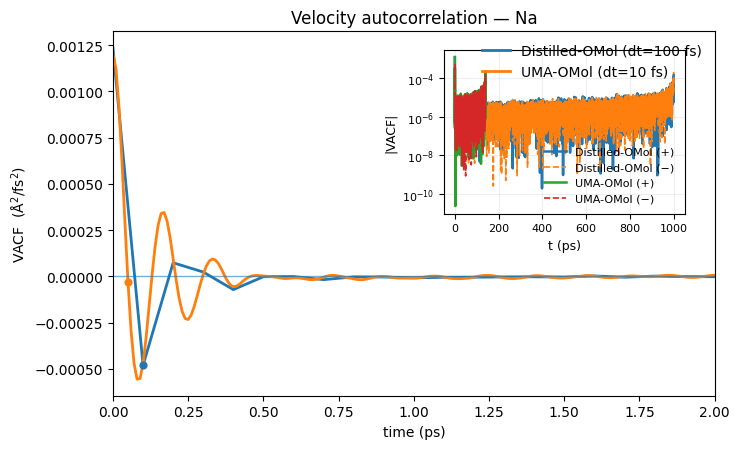

First zero-crossing (by model):
  Distilled-OMol    t0 ≈    0.100 ps   VACF(t0) = -4.812e-04 Å^2/fs^2
  UMA-OMol          t0 ≈    0.050 ps   VACF(t0) = -3.192e-05 Å^2/fs^2


In [12]:
# Plot velocity autocorrelation function (VACF) from saved CSVs
# - Expects files like: vacf_diffusion_out/VACF_<MODEL>_Na.csv with column "VACF_A2fs2"
# - Rebuilds time using dt mapping below (ignores time_ps column to be consistent with your request)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.transforms import Bbox

OUT_DIR = Path("vacf_diffusion_out")
SPECIES = "Na"

# Use these timesteps (fs)
model_dt_fs = {
    "Distilled-OMol": 100.0,   # fs
    "UMA-OMol":       10.0,  # fs
}

def first_zero_crossing(y):
    for i in range(1, len(y)):
        if y[i-1] > 0.0 and y[i] <= 0.0:
            return i
    return None

# ----- load & plot -----
plt.figure(figsize=(7.5, 4.6))

zero_marks = []

for model, dt_fs in model_dt_fs.items():
    vacf_path = OUT_DIR / f"VACF_{model}_{SPECIES}.csv"
    if not vacf_path.exists():
        print(f"[warn] Missing {vacf_path}, skipping {model}")
        continue

    df   = pd.read_csv(vacf_path)
    vacf = df["VACF_A2fs2"].to_numpy(dtype=float)      # Å^2/fs^2
    n    = len(vacf)
    t_ps = np.arange(n, dtype=float) * dt_fs * 1e-3    # rebuild time from dt

    # first zero crossing
    iz = first_zero_crossing(vacf)
    if iz is None:
        iz = n - 1

    # main plot: linear VACF
    plt.plot(t_ps, vacf, lw=2, label=f"{model} (dt={dt_fs:.0f} fs)")
    plt.scatter([t_ps[iz]], [vacf[iz]], s=24, zorder=3)

    zero_marks.append((model, t_ps[iz], vacf[iz]))

plt.axhline(0, lw=1, alpha=0.6)
plt.xlim(0,2)
plt.xlabel("time (ps)")
plt.ylabel(r"VACF  (Å$^2$/fs$^2$)")
plt.title(f"Velocity autocorrelation — {SPECIES}")
plt.legend(frameon=False)
plt.tight_layout()

# ----- inset: semilog |VACF| with sign coloring -----
# Positive in one style, negative in another; helps visualize the negative lobe
ax = plt.gca()
# place inset in upper-right corner
bbox = Bbox.from_bounds(0.55, 0.5, 0.4, 0.45)  # [x0, y0, width, height] in axes fraction
inset = ax.inset_axes([bbox.x0, bbox.y0, bbox.width, bbox.height])

for model, dt_fs in model_dt_fs.items():
    vacf_path = OUT_DIR / f"VACF_{model}_{SPECIES}.csv"
    if not vacf_path.exists():
        continue
    df   = pd.read_csv(vacf_path)
    vacf = df["VACF_A2fs2"].to_numpy(dtype=float)
    n    = len(vacf)
    t_ps = np.arange(n, dtype=float) * dt_fs * 1e-3

    pos = vacf > 0
    neg = vacf < 0
    # Plot |VACF| on semilog; use linestyle/color to indicate sign
    if pos.any():
        inset.semilogy(t_ps[pos], np.abs(vacf[pos]), lw=1.8, label=f"{model} (+)")
    if neg.any():
        inset.semilogy(t_ps[neg], np.abs(vacf[neg]), lw=1.2, ls="--", label=f"{model} (−)")

inset.set_xlabel("t (ps)", fontsize=9)
inset.set_ylabel("|VACF|", fontsize=9)
inset.tick_params(axis='both', which='major', labelsize=8)
inset.legend(frameon=False, fontsize=8)
inset.grid(alpha=0.2)

plt.show()

# Optional: quick table of zero-crossing times
if zero_marks:
    print("First zero-crossing (by model):")
    for m, tz, vz in zero_marks:
        print(f"  {m:16s}  t0 ≈ {tz:8.3f} ps   VACF(t0) = {vz: .3e} Å^2/fs^2")
